### Persons in the geographical space

We present various methods of spatialising the birthplaces of our population.

The data was prepared using the queries [documented on this page](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da2-birth-places.sql)

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
from shapely import wkt

import scipy.stats as stats
import math

from geopandas.tools import sjoin
#from geodatasets import get_path

In [142]:
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go


from pathlib import Path


import json

import numpy as np
import seaborn as sns
import math
import os

In [3]:
import warnings
warnings.filterwarnings('ignore')


In [4]:

import pprint
import csv


from shutil import copyfile


## Geo data

Documentation: [Geographical Information System](https://en.wikipedia.org/wiki/Geographic_information_system) (Wikipedia)

<img src=./doc_images/DatendimensionenImGIS.jpg alt="geodata" width="50%">  
Par F Lamiot d'après [1] (GNUFDL) — source, CC BY-SA 3.0, https://commons.wikimedia.org/w/index.php?curid=3831140


### Source des données spatiales
[Word Regions (ESRI)](https://hub.arcgis.com/datasets/a79a3e4dc55343b08543b1b6133bfb90/explore?location=-0.027457%2C0.000000%2C0.88). For personal use only, data under copyright !

In [5]:
world_filepath = 'geo_data/World_Regions_6144914380456424035.geojson'
## dataframe GeoPandas
world = gpd.read_file(world_filepath)
world.head()

,FID,REGION,SQMI,SQKM,geometry
0,1,Asiatic Russia,4.987737e+06,1.291823e+07,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,2,Australia/New Zealand,3.077219e+06,7.969992e+06,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967..."
2,3,Caribbean,8.919361e+04,2.310113e+05,"MULTIPOLYGON (((-60.92305 10.79722, -60.94445 ..."
3,4,Central America,9.576923e+05,2.480422e+06,"MULTIPOLYGON (((-81.67847 7.38861, -81.64945 7..."
4,5,Central Asia,1.612212e+06,4.175626e+06,"POLYGON ((53.90564 37.35086, 53.67731 37.33536..."


### Basic GIS notions

* [Geographic information system - GIS](https://en.wikipedia.org/wiki/Geographic_information_system)
* [Geoid](https://en.wikipedia.org/wiki/Geoid)
* [Earth ellipsoid](https://en.wikipedia.org/wiki/Earth_ellipsoid): WGS84
* [Spatial reference system - SRS/CRS](https://en.wikipedia.org/wiki/Spatial_reference_system)
* [EPSG Geodetic Parameter Dataset](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset): EPSG:4326, EPSG:3857, EPSG:9989

In [6]:
### Inspect the projection
pprint.pprint(world.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



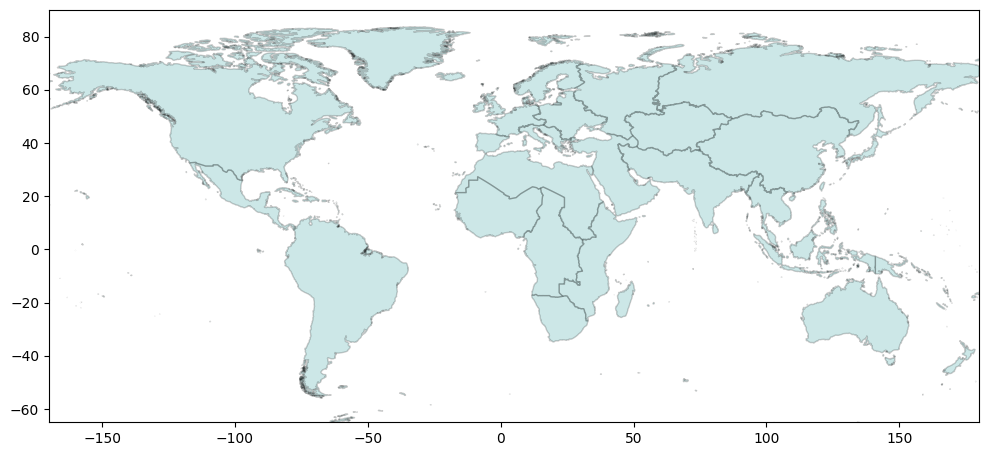

In [7]:
### Draw the world map

## GeoPandas documentation
# https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html

# If we want to exclude the Antarctic region
world.clip([-180.0, -10.0, 180.0, 90.0])

ax = world.plot(color="DarkCyan", alpha=0.2, edgecolor="black", figsize=(12,9))

# If we want to exclude the Antarctic region
ax.set_xlim(-170,180)
ax.set_ylim(-65, 90)


plt.show()



## Import the data

The data is available in the da_data directory and was prepared using the query [documented on this page](../../documentation/wikidata/data-analysis/da1-distribution-of-births-in-time.md)

In [6]:
## create variable declaring the path to the data
path_to_data = 'da_data/da2-birth-place.csv'

In [7]:
## creating a Pandas Dataframe (data container in form of a table) 
df_p = pd.read_csv(path_to_data, sep=",", encoding="utf-8", header=0)
df_p.columns = ['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace',
                'geometry','uriPlace']

## first rows of the dataframe
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT(10.093611 48.837222),http://www.wikidata.org/entity/Q3951
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT(8.617500 56.358056),http://www.wikidata.org/entity/Q27678
2,http://www.wikidata.org/entity/Q100153910,Frank J. Blatt,1924,male,Vienna,POINT(16.372500 48.208333),http://www.wikidata.org/entity/Q1741
3,http://www.wikidata.org/entity/Q100155322,Edgar Knobloch,1953,male,Prague,POINT(14.421389 50.087500),http://www.wikidata.org/entity/Q1085
4,http://www.wikidata.org/entity/Q100169285,Robert M. Winglee,1958,male,Sydney,POINT(151.210000 -33.867778),http://www.wikidata.org/entity/Q3130


In [8]:
## Basic infor about the DataFrame
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22080 entries, 0 to 22079
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      22080 non-null  object
 1   labelPer    22080 non-null  object
 2   birthYear   22080 non-null  int64 
 3   gender      21986 non-null  object
 4   labelPlace  22080 non-null  object
 5   geometry    22080 non-null  object
 6   uriPlace    22080 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.2+ MB


## Inspect the data


In [9]:
### Add column names and inspect length of dataframe

print('Number: ',len(df_p))
df_p.iloc[10:13,:]

Number:  22080


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
10,http://www.wikidata.org/entity/Q100235232,Joseph Johnson III,1940,male,Nashville,POINT(-86.774444 36.162222),http://www.wikidata.org/entity/Q23197
11,http://www.wikidata.org/entity/Q100273146,Robert Meldrum Stewart,1878,male,Gladstone,POINT(-98.950000 50.225800),http://www.wikidata.org/entity/Q63761
12,http://www.wikidata.org/entity/Q100276765,Charles-Henri Tabareau,1790,male,Béziers,POINT(3.216111 43.343333),http://www.wikidata.org/entity/Q174019


### Treat multiple birth places

Verify that persons are unique:
* are there some persons with multiple birth places, etc.?
  * If Pandas *is_unique* method: 'true' they are unique, so no multiple.
  * If 'false': multiple rows per person
* If you have multiple persons go back to the SQL part and clean up using GROUP BY -> MIN  

In [10]:
### Tests if the values in the column are unique
# If unique result : True (boolean value not string !)
is_unique=df_p.uriPer.is_unique
print(is_unique)

True


## Group and map birth places

"Well-known text (WKT) is a text markup language for representing vector geometry objects" ([Wikipedia](https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry))

In [11]:
### Group and count the number of persons per birth place
p_gr = df_p.groupby(by=['uriPlace', 'labelPlace', 'geometry'], as_index=False).size()
p_gr.columns=['uriPlace', 'labelPlace', 'geometry', 'size']
p_gr.sort_values('size', ascending=False).head()


,uriPlace,labelPlace,geometry,size
6879,http://www.wikidata.org/entity/Q649,Moscow,POINT(37.617500 55.750556),493
6810,http://www.wikidata.org/entity/Q64,Berlin,POINT(13.383333 52.516667),341
6943,http://www.wikidata.org/entity/Q656,Saint Petersburg,POINT(30.316667 59.950000),299
6611,http://www.wikidata.org/entity/Q60,New York City,POINT(-74.006111 40.712778),274
2059,http://www.wikidata.org/entity/Q1741,Vienna,POINT(16.372500 48.208333),266


In [12]:
### Try first to convert WKT into Point Geometry
# using a geopandas feature
try:
    p_gr['geometry'] = p_gr['geometry'].apply(wkt.loads)
except Exception as e:
    print(e)

ParseException: Unknown type: '_:BN1612906'


In [13]:
### there are wrong values in the data: find them
# all the rows where the geometry field does not contain the string 'POINT'
df_p.loc[~df_p.geometry.str.contains('POINT')]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
15083,http://www.wikidata.org/entity/Q5078030,Charles Gifford,1861,male,at sea,_:bn1612906,http://www.wikidata.org/entity/Q55438959


In [14]:
### Drop the rows with the wrong value
df_p=df_p.loc[df_p.geometry.str.contains('POINT')]

In [15]:
### Re-do grouping after cleaning up
p_gr = df_p.groupby(by=['uriPlace', 'labelPlace', 'geometry'], as_index=False).size()
p_gr.columns=['uriPlace', 'labelPlace', 'geometry', 'number']
p_gr.sort_values('number', ascending=False).head(2)


,uriPlace,labelPlace,geometry,number
6878,http://www.wikidata.org/entity/Q649,Moscow,POINT(37.617500 55.750556),493
6809,http://www.wikidata.org/entity/Q64,Berlin,POINT(13.383333 52.516667),341


In [16]:

### Create a dataframe with the POINT geometry
# https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html
birth_gdf = gpd.GeoDataFrame(
    p_gr, 
    ### Use this if no conversion before to geometry
    ## Cf. above:  p_gr['geometry'].apply(wkt.loads)
    geometry=gpd.GeoSeries.from_wkt(p_gr.geometry), 
    crs=4326
)

birth_gdf.sort_values('number', ascending=False).head(2)



,uriPlace,labelPlace,geometry,number
6878,http://www.wikidata.org/entity/Q649,Moscow,POINT (37.6175 55.75056),493
6809,http://www.wikidata.org/entity/Q64,Berlin,POINT (13.38333 52.51667),341


In [17]:
### The Python class of the object changed 
# WKT strings are now points
print(p_gr.geometry.dtype, '->', birth_gdf.geometry.dtype)

object -> geometry


In [18]:
### Inspect the projection
pprint.pprint(birth_gdf.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



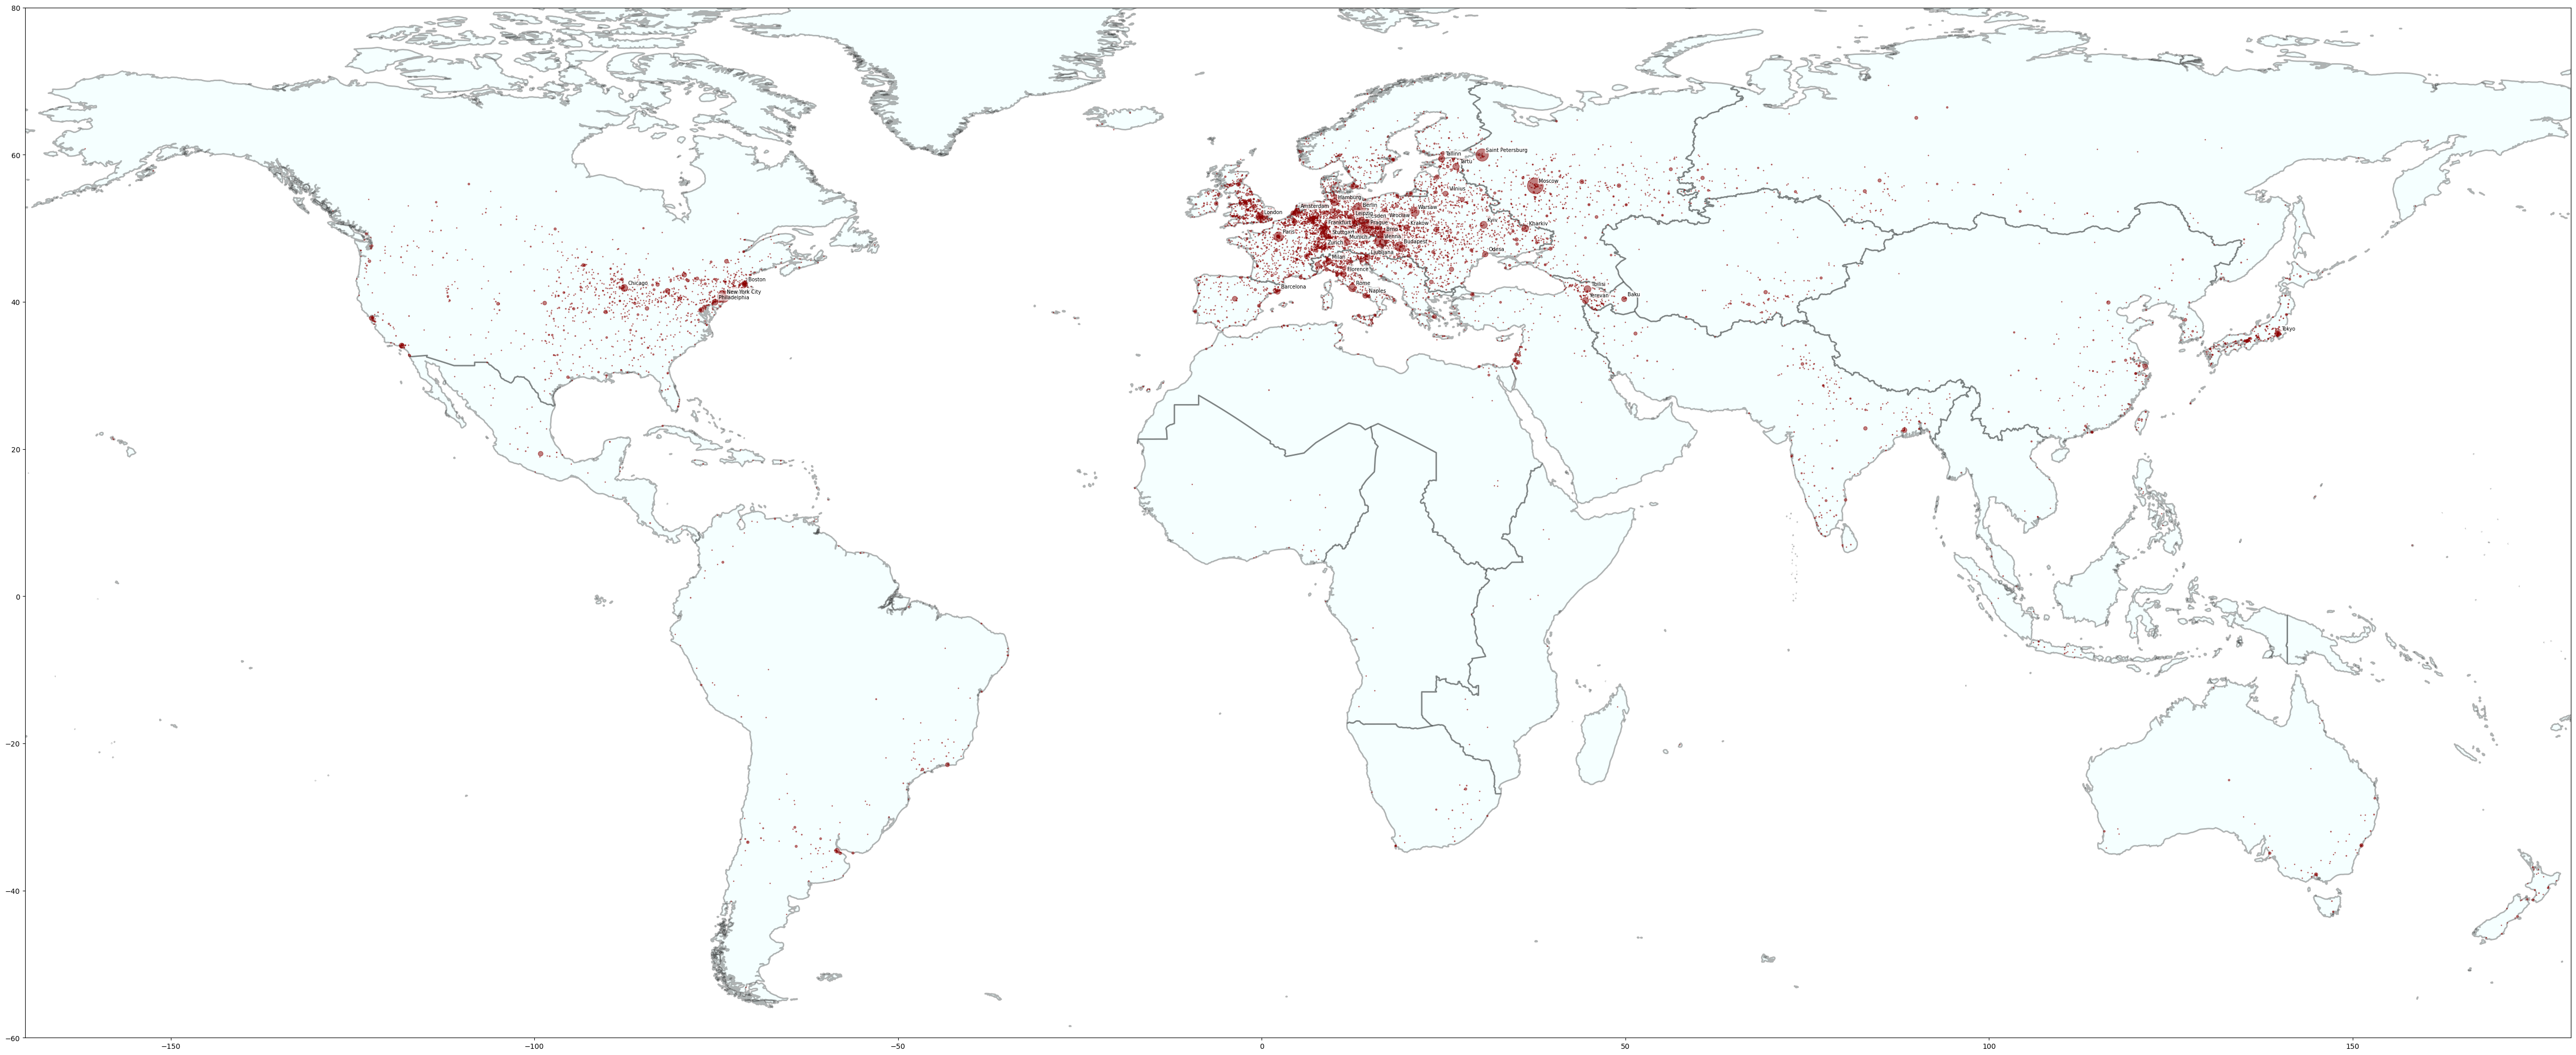

Done -> inspect picture


In [214]:
### Draw the world map


ax = world.plot(color="LightCyan", alpha=0.3, 
                edgecolor="black", linewidth=2, figsize=(64,48))

# If we want to exclude the Antarctic region
ax.set_xlim(-170,180)
ax.set_ylim(-60, 80)

# We can now plot our ``GeoDataFrame``.
birth_gdf.plot(ax=ax, color="DarkRed", markersize='number', alpha=0.5)
# Add labels where number > 100
for _, row in birth_gdf[birth_gdf['number'] > 50].iterrows():
    ax.annotate(
        text=row['labelPlace'],          # e.g. "Boston"
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),              # offset in points
        textcoords="offset points",
        fontsize=7,
        color="Black",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.7
        )
    )

f_address = "images/birth_places_geopandas.png"
plt.savefig(f_address, bbox_inches='tight', pad_inches=0.05, dpi=150)
plt.show()
print('Done -> inspect picture')
plt.close()

## Experiment with different kinds of maps

In [22]:
birth_gdf.head(1)

,uriPlace,labelPlace,geometry,number
0,http://www.wikidata.org/entity/Q100,Boston,POINT (-71.05778 42.36028),57


In [23]:
### Create columns for long / lat
birth_gdf['long'] = birth_gdf['geometry'].x
birth_gdf['lat'] = birth_gdf['geometry'].y
birth_gdf.head(1)

,uriPlace,labelPlace,geometry,number,long,lat
0,http://www.wikidata.org/entity/Q100,Boston,POINT (-71.05778 42.36028),57,-71.057778,42.360278


In [24]:
birth_gdf_plus1 = birth_gdf.loc[birth_gdf.number>1]
print(birth_gdf_plus1[["lat", "long"]].head(10))
print(birth_gdf_plus1[["lat", "long"]].describe())
print(birth_gdf_plus1.crs)

          lat       long
0   42.360278 -71.057778
3   49.231162  13.520208
5   49.431397  15.223389
6   50.162871  16.274955
7   49.706391  14.898854
15  52.265556   6.793056
21  38.904722  46.023055
22  52.555000   5.919722
23  46.768910  23.590660
27  55.413400  -1.706910
               lat         long
count  2132.000000  2132.000000
mean     43.669657     9.163303
std      15.842979    55.421610
min     -46.429000  -157.857222
25%      40.949166    -0.167800
50%      48.010000    11.429583
75%      51.480417    25.600000
max      66.416667   176.917778
EPSG:4326


In [25]:
### We explore different ways of normalizing the data,
## i.e. diminishing the difference between high and low values
# p_size = [int(s/10+2) for s in birth_gdf_plus1['number']]
# p_size = [int(s) for s in birth_gdf_plus1['number']]
p_size = [(math.log(s)) for s in birth_gdf_plus1['number']]
max(p_size)

6.20050917404269

In [ ]:

fig = px.scatter_map(
    birth_gdf_plus1, lat="lat", lon="long", size=p_size,
    hover_name="labelPlace", hover_data=["number"],
    opacity=0.8, zoom=3.5,
    center=dict(lon=8.5, lat=47),
    height=1000
)

fig.update_traces(marker=dict(color="GreenYellow", sizemin=0.2))

fig.update_layout(
    map=dict(
        style={
            "version": 8,
            "sources": {
                "usgs": {
                    "type": "raster",
                    "tiles": ["https://basemap.nationalmap.gov/arcgis/rest/services/USGSImageryOnly/MapServer/tile/{z}/{y}/{x}"],
                    "tileSize": 256
                }
            },
            "layers": [{
                "id": "usgs-layer",
                "type": "raster",
                "source": "usgs"
            }]
        },
        center=dict(lon=8.5, lat=47),
        zoom=3.5
    )
)

#fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
f_address = "interactive_images/birth_places_geological_survey.html"
fig.write_html(f_address)
print('Done -> inspect picture')
# fig.show()
plt.close()

In [27]:
### Open the world regions ESRI file in geojson format (and not dataframe)
with open('geo_data/World_Regions_6144914380456424035.geojson') as f:
    geojson = json.load(f)

geojson['features'][3]['properties']


{'FID': 4,
 'REGION': 'Central America',
 'SQMI': 957692.30734,
 'SQKM': 2480421.615}

In [ ]:
### 

p_size = [int(s/10+2) for s in birth_gdf_plus1['number']]

fig = px.scatter_map(birth_gdf_plus1, lat="lat", lon="long", size=p_size, 
                     hover_name="labelPlace", 
                        color_discrete_sequence=["DodgerBlue"],  zoom=3.5,
                        center=dict(lon=8.5, lat=47),height=600,
                        opacity=0.9)
fig.update_layout(
    map_style="white-bg",
    map_layers=[
        {
            "below": 'traces',
            "sourcetype": "geojson",
            "type":"line",
            "sourceattribution": "ESRI",
            "source": geojson,
            "line": {"width": 0.5},
        }
      ])

f_address = "interactive_images/birth_places_regions.html"
fig.write_html(f_address, include_plotlyjs='cdn')
#fig.show()

### Plot the world as a sphere

In [ ]:
### Plot on world as a sphere

lon = birth_gdf["long"]
lat= birth_gdf["lat"]
label= birth_gdf["labelPlace"]
size=[s/10 + 3 for s in birth_gdf["number"]]


# Create the figure
fig = go.Figure(data=go.Scattergeo(
    lon=lon,
    lat=lat,
    mode='markers+text',
    marker=dict(size=size,
                color='red'),
    hovertext=label,
    textposition='top center',
    hoverinfo='text',
    hoverlabel=dict(
        bgcolor='white',
        font_size=12,
        font_family='Arial'
    )
))

# Set the projection to orthogonal
fig.update_layout(
    width=800, 
    height=800,
    geo=dict(
        projection=dict(
            type='orthographic'
        )
    )
)

f_address = "interactive_images/birth_places_globus.html"
fig.write_html(f_address, include_plotlyjs='cdn')
# Show the plot
#fig.show()

### Join regions and inspect

We use here spatial joins and associate a region to each place

In [19]:
birth_gdf.loc[birth_gdf.labelPlace.str.contains('Petersburg') |
              birth_gdf.labelPlace.str.contains('Moscow')
              ].sort_values('number', ascending=False).head(10)

,uriPlace,labelPlace,geometry,number
6878,http://www.wikidata.org/entity/Q649,Moscow,POINT (37.6175 55.75056),493
6942,http://www.wikidata.org/entity/Q656,Saint Petersburg,POINT (30.31667 59.95),299
1962,http://www.wikidata.org/entity/Q1697,Moscow Oblast,POINT (37.738 55.628),4
607,http://www.wikidata.org/entity/Q1137842,Moscow Governorate,POINT (37.61778 55.75167),2
5180,http://www.wikidata.org/entity/Q4225245,"Kobylino, Moscow Oblast",POINT (35.69139 55.96056),1
5813,http://www.wikidata.org/entity/Q49512,Saint Petersburg Governorate,POINT (30.31667 59.95),1
5993,http://www.wikidata.org/entity/Q511964,Petersburg,POINT (-77.40042 37.21295),1


In [20]:
### GeoPandas spatial join

w_birth_gdf= birth_gdf.sjoin(world)
w_birth_gdf.iloc[[1,5,10]]

,uriPlace,labelPlace,geometry,number,index_right,FID,REGION,SQMI,SQKM
1,http://www.wikidata.org/entity/Q1000029,Kraslice,POINT (12.51756 50.32384),1,7,8,Eastern Europe,729308.96514,1.888909e+06
5,http://www.wikidata.org/entity/Q1000073,Pelhřimov,POINT (15.22339 49.4314),4,7,8,Eastern Europe,729308.96514,1.888909e+06
10,http://www.wikidata.org/entity/Q100046,Cavezzo,POINT (11.03071 44.83703),1,18,19,Southern Europe,503015.12202,1.302808e+06


In [21]:
### Number of regions
print(len(world))
world.head(1)

25


,FID,REGION,SQMI,SQKM,geometry
0,1,Asiatic Russia,4.987737e+06,12918232.32,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [22]:
### Count by region (sum number of each place in the region)
swb = w_birth_gdf.groupby(['FID','REGION'], as_index=False)['number'].sum()
#swb = swb.set_index('FID', drop=False)
print(len(swb))
swb.sort_values('number', ascending=False).head(24)


23


,FID,REGION,number
20,22,Western Europe,5538
7,8,Eastern Europe,4548
21,23,Northern America,2795
17,19,Southern Europe,1935
22,24,Northern Europe,1687
8,9,European Russia,1665
6,7,Eastern Asia,862
19,21,Western Asia,621
16,18,Southern Asia,445
13,15,South America,337


In [23]:
### Find places in European Russia with most births 
w_birth_gdf.loc[w_birth_gdf.FID==9].sort_values('number',ascending=False).head(2)

,uriPlace,labelPlace,geometry,number,index_right,FID,REGION,SQMI,SQKM
6878,http://www.wikidata.org/entity/Q649,Moscow,POINT (37.6175 55.75056),493,8,9,European Russia,1.541719e+06,3993050.089
6942,http://www.wikidata.org/entity/Q656,Saint Petersburg,POINT (30.31667 59.95),299,8,9,European Russia,1.541719e+06,3993050.089


In [24]:
### Normal Pandas join: add polygons to aggregated regions 
geom_swb=pd.merge(world, swb, left_on='FID', right_on='FID', 
                  how='left')

geom_swb.head(3)

,FID,REGION_x,SQMI,SQKM,geometry,REGION_y,number
0,1,Asiatic Russia,4.987737e+06,1.291823e+07,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580...",Asiatic Russia,293.0
1,2,Australia/New Zealand,3.077219e+06,7.969992e+06,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967...",Australia/New Zealand,190.0
2,3,Caribbean,8.919361e+04,2.310113e+05,"MULTIPOLYGON (((-60.92305 10.79722, -60.94445 ...",Caribbean,16.0


In [25]:
"""grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
"""
### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
geom_swb["geometry"] = (
    geom_swb.simplify(tolerance=0.5)
)

In [215]:
### range
max = geom_swb.number.max()

# Create the choropleth map
fig = px.choropleth_map(
    geom_swb,
    geojson=geom_swb.__geo_interface__,
    map_style='white-bg',
    locations=geom_swb.index,
    color='number',  # Replace with your actual column name
    color_continuous_scale='Blues',
    range_color=(0, max),  # Replace with your actual range
    zoom=1,
    hover_name='REGION_x',
    center={'lat': 47, 'lon': 8.5},
    height=600,
    width=800

)

f_address = "interactive_images/birth_places_regions_choropleth.html"
fig.write_html(f_address, include_plotlyjs='cdn')
# Show the plot
#fig.show()

## Analyse using periods

In [27]:
### Imputed activity periods
l_10 = list(range(1781, 1991, 10))
print(l_10[:5],l_10[-5:])

[1781, 1791, 1801, 1811, 1821] [1941, 1951, 1961, 1971, 1981]


In [28]:
### convert birthYear to integer
df_p.birthYear = df_p.birthYear.apply(lambda x : int(x))

In [29]:
try:
    df_p = df_p.drop('len_coord', axis=1)
except Exception as e:
    print(e)
df_p.head(2)

"['len_coord'] not found in axis"


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT(10.093611 48.837222),http://www.wikidata.org/entity/Q3951
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT(8.617500 56.358056),http://www.wikidata.org/entity/Q27678


In [30]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année
df_p['periods'] = pd.cut(df_p['birthYear'], l_10, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
df_p['periods'] = df_p['periods'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

df_p=df_p.sort_values(by='periods')

# Inspection
df_p.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT(11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790
10198,http://www.wikidata.org/entity/Q252265,Theodor von Grotthuss,1785,male,Leipzig,POINT(12.374733 51.340632),http://www.wikidata.org/entity/Q2079,1781-1790
14595,http://www.wikidata.org/entity/Q4740382,Amasa Holcomb,1787,male,Southwick,POINT(-72.770833 42.054722),http://www.wikidata.org/entity/Q2302156,1781-1790


In [31]:
p_gr_per = df_p.groupby(by=['uriPlace', 'labelPlace', 'periods', 'geometry'], observed=True, as_index=False).size()
p_gr_per.columns=['uriPlace', 'labelPlace', 'period', 'coordinates', 'size']
#p_grp.geometry = gpd.GeoSeries.from_wkt(p_gr["coordinates"])
p_gr_per=p_gr_per.sort_values(by='period')
p_gr_per.head()


,uriPlace,labelPlace,period,coordinates,size
8341,http://www.wikidata.org/entity/Q38380,Angers,1781-1790,POINT(-0.555555 47.472778),1
4959,http://www.wikidata.org/entity/Q20485,Santa Vittoria d'Alba,1781-1790,POINT(7.933333 44.700000),1
10741,http://www.wikidata.org/entity/Q544501,Stadthagen,1781-1790,POINT(9.206944 52.324722),1
10830,http://www.wikidata.org/entity/Q5540,Penza,1781-1790,POINT(45.000000 53.200000),1
4632,http://www.wikidata.org/entity/Q196786,Uglich,1781-1790,POINT(38.333333 57.533333),1


In [32]:

### Create a Geopandas geometry column
# https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html
birth_p_grp = gpd.GeoDataFrame(
    p_gr_per, 
    ### Here we use it
    geometry=gpd.GeoSeries.from_wkt(p_gr_per.coordinates), crs=4326
)

birth_p_grp.head(3)



,uriPlace,labelPlace,period,coordinates,size,geometry
8341,http://www.wikidata.org/entity/Q38380,Angers,1781-1790,POINT(-0.555555 47.472778),1,POINT (-0.55556 47.47278)
4959,http://www.wikidata.org/entity/Q20485,Santa Vittoria d'Alba,1781-1790,POINT(7.933333 44.700000),1,POINT (7.93333 44.7)
10741,http://www.wikidata.org/entity/Q544501,Stadthagen,1781-1790,POINT(9.206944 52.324722),1,POINT (9.20694 52.32472)


In [33]:
### Create columns for long / lat
birth_p_grp['long'] = birth_p_grp['geometry'].x
birth_p_grp['lat'] = birth_p_grp['geometry'].y
birth_p_grp.head()

,uriPlace,labelPlace,period,coordinates,size,geometry,long,lat
8341,http://www.wikidata.org/entity/Q38380,Angers,1781-1790,POINT(-0.555555 47.472778),1,POINT (-0.55556 47.47278),-0.555555,47.472778
4959,http://www.wikidata.org/entity/Q20485,Santa Vittoria d'Alba,1781-1790,POINT(7.933333 44.700000),1,POINT (7.93333 44.7),7.933333,44.700000
10741,http://www.wikidata.org/entity/Q544501,Stadthagen,1781-1790,POINT(9.206944 52.324722),1,POINT (9.20694 52.32472),9.206944,52.324722
10830,http://www.wikidata.org/entity/Q5540,Penza,1781-1790,POINT(45.000000 53.200000),1,POINT (45 53.2),45.000000,53.200000
4632,http://www.wikidata.org/entity/Q196786,Uglich,1781-1790,POINT(38.333333 57.533333),1,POINT (38.33333 57.53333),38.333333,57.533333


In [34]:
# now just plot it on a map with evolution by time
# https://plotly.com/python/animations/
# https://plotly.com/python/scatter-plots-on-maps/

# np.log(s) * 1000
size = [s*5 if s != 0 else 0 for s in birth_p_grp["size"]]




fig = px.scatter_geo(
    birth_p_grp,
    lon="long",
    lat="lat",
    size=size,
    hover_name = "labelPlace",
    animation_frame= "period",
    width=1400, height=600,
    color_discrete_sequence=['red'],
    title="Evolution of birth places through time"
)
    
fig.layout.updatemenus[0].buttons[0].args[1]["frame"] = {"duration": 1500, "redraw": True}
fig.layout.updatemenus[0].buttons[0].args[1]["transition"] = {"duration": 800, "easing": "cubic-in-out"}


fig.update_layout(
    mapbox={"style": "carto-positron", "zoom":2},
    margin={"l": 0, "r": 20, "t": 30, "b": 200}
)



fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 20

### Enregistrer l'image, puis l'ouvrir dans un autre onglet du navigateur
f_address = "interactive_images/birth_places_periods.html"
fig.write_html(f_address, include_plotlyjs='cdn')
#fig.show()
plt.close()


### Merge persons and territories

This merge provides regions as additional properties of persons

In [54]:
with open('geo_data/World_Regions_6144914380456424035.geojson') as f:
    geojson = json.load(f)

pprint.pprint(geojson['features'][3]['properties'])

{'FID': 4,
 'REGION': 'Central America',
 'SQKM': 2480421.615,
 'SQMI': 957692.30734}


In [55]:
print([f['properties']['FID'] for f in geojson['features']][:3])

[1, 2, 3]


In [56]:
## dataframe GeoPandas from geojson features
world = gpd.GeoDataFrame.from_features(geojson['features'])
### this is needed with this import procedure
world.set_crs(epsg=4326, inplace=True)
world.head()

,geometry,FID,REGION,SQMI,SQKM
0,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580...",1,Asiatic Russia,4.987737e+06,1.291823e+07
1,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967...",2,Australia/New Zealand,3.077219e+06,7.969992e+06
2,"MULTIPOLYGON (((-60.92305 10.79722, -60.94445 ...",3,Caribbean,8.919361e+04,2.310113e+05
3,"MULTIPOLYGON (((-81.67847 7.38861, -81.64945 7...",4,Central America,9.576923e+05,2.480422e+06
4,"POLYGON ((53.90564 37.35086, 53.67731 37.33536...",5,Central Asia,1.612212e+06,4.175626e+06


In [57]:
### Inspect the projection
pprint.pprint(world.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



In [58]:
world_filepath = 'geo_data/World_Regions_6144914380456424035.geojson'
## dataframe GeoPandas
world = gpd.read_file(world_filepath)
world.head()

,FID,REGION,SQMI,SQKM,geometry
0,1,Asiatic Russia,4.987737e+06,1.291823e+07,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,2,Australia/New Zealand,3.077219e+06,7.969992e+06,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967..."
2,3,Caribbean,8.919361e+04,2.310113e+05,"MULTIPOLYGON (((-60.92305 10.79722, -60.94445 ..."
3,4,Central America,9.576923e+05,2.480422e+06,"MULTIPOLYGON (((-81.67847 7.38861, -81.64945 7..."
4,5,Central Asia,1.612212e+06,4.175626e+06,"POLYGON ((53.90564 37.35086, 53.67731 37.33536..."


In [59]:
### Cleaned up dataframe
df_p.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT(11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790
10198,http://www.wikidata.org/entity/Q252265,Theodor von Grotthuss,1785,male,Leipzig,POINT(12.374733 51.340632),http://www.wikidata.org/entity/Q2079,1781-1790
14595,http://www.wikidata.org/entity/Q4740382,Amasa Holcomb,1787,male,Southwick,POINT(-72.770833 42.054722),http://www.wikidata.org/entity/Q2302156,1781-1790


In [60]:
### create a geo data frame

gdf_p = gpd.GeoDataFrame(
    df_p, 
    ### Here we use it
    geometry=gpd.GeoSeries.from_wkt(df_p.geometry), crs=4326
)

gdf_p.head(3)



,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
18784,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.57861 46.06028),http://www.wikidata.org/entity/Q654153,1781-1790
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790
20074,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.03306 48.13972),http://www.wikidata.org/entity/Q752334,1781-1790


In [61]:
### Number of persons before join
print(len(gdf_p))

22079


In [185]:
### spatial join : if POINT is inside REGION -> join 
# per person we add the region of birth
pgr_reg = gdf_p.sjoin(world)
pgr_reg.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,FID,REGION,SQMI,SQKM
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,21,22,Western Europe,4.233073e+05,1.096365e+06
10198,http://www.wikidata.org/entity/Q252265,Theodor von Grotthuss,1785,male,Leipzig,POINT (12.37473 51.34063),http://www.wikidata.org/entity/Q2079,1781-1790,21,22,Western Europe,4.233073e+05,1.096365e+06
14595,http://www.wikidata.org/entity/Q4740382,Amasa Holcomb,1787,male,Southwick,POINT (-72.77083 42.05472),http://www.wikidata.org/entity/Q2302156,1781-1790,22,23,Northern America,8.292643e+06,2.147793e+07


In [70]:
### There are somme issues with the spatial join and 
### around 600 persons are 'lost'
print(len(pgr_reg))

21445


In [186]:
### drop not neede column
pgr_reg = pgr_reg.drop([ 'index_right', 'SQMI','SQKM'], axis=1)
pgr_reg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION
18784,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.57861 46.06028),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe


#### Prepare the data for the bivariate analysis, cf. challenge da3

In [72]:
file_address='da_data/da3-birthYear-gender-region.csv'
pgr_reg.to_csv(file_address, index=False)

## Merge persons and countries

In [187]:
### Source Eurostat: https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units/countries
## © EuroGeographics for the administrative boundaries
countries_filepath = 'geo_data/CNTR_RG_03M_2024_4326.geojson'
## dataframe GeoPandas
countries = gpd.read_file(countries_filepath)
countries.head()

,CNTR_ID,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,DJ,جيبوتي-Djibouti-Jabuuti,Djibouti,Djibouti,DJI,UN Member State,Djibouti,F,F,F,Dschibuti,"MULTIPOLYGON (((43.15633 12.64836, 43.29442 12..."
1,DK,Danmark,Denmark,Danemark,DNK,UN Member State,Copenhagen,T,F,F,Dänemark,"MULTIPOLYGON (((15.11729 55.01314, 15.06971 54..."
2,DM,Dominica-Dominique,Dominica,Dominique,DMA,UN Member State,Roseau,F,F,F,Dominica,"POLYGON ((-61.25941 15.25229, -61.27394 15.243..."
3,DO,República Dominicana,Dominican Republic,République dominicaine,DOM,UN Member State,Santo Domingo,F,F,F,Dominikanische Republik,"MULTIPOLYGON (((-70.80653 19.874, -70.77783 19..."
4,DZ,الجزائر,Algeria,Algérie,DZA,UN Member State,Algiers,F,F,F,Algerien,"POLYGON ((7.21824 37.08802, 7.27244 37.06817, ..."


In [188]:
countries.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   CNTR_ID    263 non-null    object  
 1   CNTR_NAME  263 non-null    object  
 2   NAME_ENGL  263 non-null    object  
 3   NAME_FREN  244 non-null    object  
 4   ISO3_CODE  263 non-null    object  
 5   SVRG_UN    263 non-null    object  
 6   CAPT       233 non-null    object  
 7   EU_STAT    263 non-null    object  
 8   EFTA_STAT  263 non-null    object  
 9   CC_STAT    263 non-null    object  
 10  NAME_GERM  243 non-null    object  
 11  geometry   263 non-null    geometry
dtypes: geometry(1), object(11)
memory usage: 24.8+ KB


In [189]:
pprint.pprint(countries.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



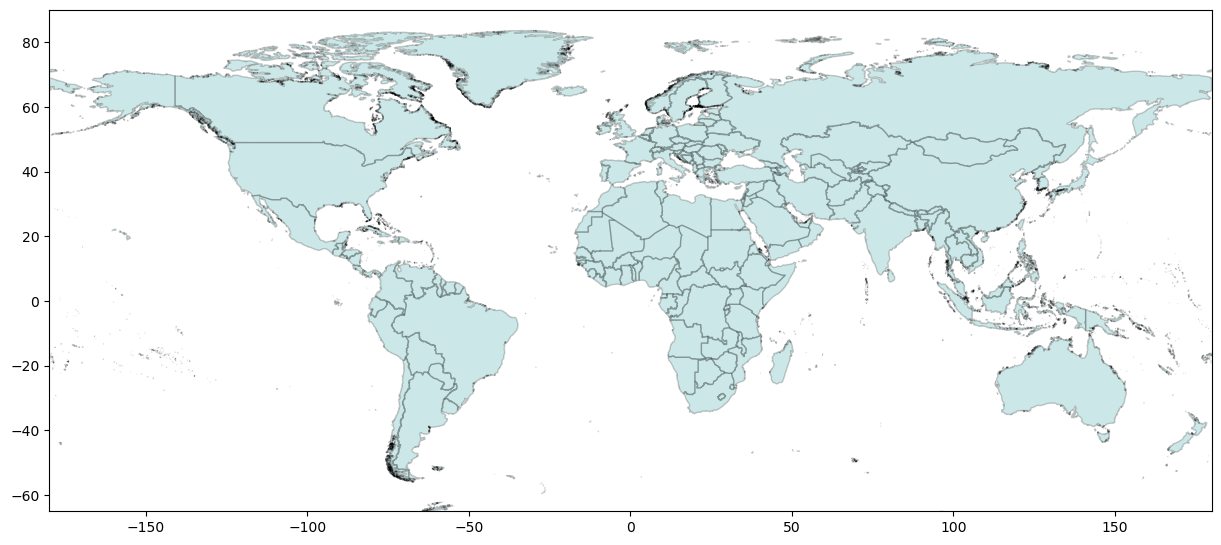

In [190]:
### Draw the world map with the countries

## GeoPandas documentation
# https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html

# If we want to exclude the Antarctic region
#countries.clip([-180.0, -10.0, 180.0, 90.0])

ax = countries.plot(color="DarkCyan", alpha=0.2, edgecolor="black", figsize=(15,10))

# If we want to exclude the Antarctic region
ax.set_xlim(-180,180)
ax.set_ylim(-65, 90)


plt.show()



In [191]:
### spatial join : if POINT is inside REGION -> join 
# per person we add the country of birth
pgr_reg_countries = pgr_reg.sjoin(countries)
pgr_reg_countries.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,...,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,...,Deutschland,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland
10198,http://www.wikidata.org/entity/Q252265,Theodor von Grotthuss,1785,male,Leipzig,POINT (12.37473 51.34063),http://www.wikidata.org/entity/Q2079,1781-1790,22,Western Europe,...,Deutschland,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland
14595,http://www.wikidata.org/entity/Q4740382,Amasa Holcomb,1787,male,Southwick,POINT (-72.77083 42.05472),http://www.wikidata.org/entity/Q2302156,1781-1790,23,Northern America,...,United States,United States,États-Unis,USA,UN Member State,"Washington, D.C.",F,F,F,Vereinigten Staaten


In [192]:
### Liyt of column names
print(pgr_reg_countries.columns)

Index(['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'geometry',
       'uriPlace', 'periods', 'FID', 'REGION', 'index_right', 'CNTR_ID',
       'CNTR_NAME', 'NAME_ENGL', 'NAME_FREN', 'ISO3_CODE', 'SVRG_UN', 'CAPT',
       'EU_STAT', 'EFTA_STAT', 'CC_STAT', 'NAME_GERM'],
      dtype='object')


In [193]:
### drop not needed columns
pgr_reg_countries = pgr_reg_countries.drop([ 'index_right', 'NAME_FREN', 'SVRG_UN', 'CAPT',
       'EU_STAT', 'EFTA_STAT', 'CC_STAT', 'NAME_GERM'], axis=1)
pgr_reg_countries.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE
18784,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.57861 46.06028),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU


### Clean up gender variable

In [194]:
print(pgr_reg_countries.groupby(by='gender').size())

gender
female                 1654
male                  19652
trans man                 1
trans woman               3
undisclosed gender        1
dtype: int64


In [195]:
### Limit to female/male for statistic treatment
pgr_reg_countries=pgr_reg_countries[pgr_reg_countries.gender.isin(['female', 'male'])]

In [196]:
print(pgr_reg_countries.groupby(by='gender').size())

gender
female     1654
male      19652
dtype: int64


### Prepare the data for the bivariate analysis, cf. challenge da3

In [197]:
file_address='da_data/da3-birthYear-gender-region-country.csv'
pgr_reg_countries.to_csv(file_address, index=False)

In [198]:
### Create columns for long / lat
pgr_reg_countries['long'] = pgr_reg_countries['geometry'].x
pgr_reg_countries['lat'] = pgr_reg_countries['geometry'].y
pgr_reg_countries.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,long,lat
18784,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.57861 46.06028),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,6.578611,46.060278
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,11.076389,51.464722
20074,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.03306 48.13972),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,23.033056,48.139722
13653,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1781,male,Stadthagen,POINT (9.20694 52.32472),http://www.wikidata.org/entity/Q544501,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,9.206944,52.324722
9508,http://www.wikidata.org/entity/Q22331669,Carlo Brioschi,1782,male,Milan,POINT (9.19 45.46694),http://www.wikidata.org/entity/Q490,1781-1790,19,Southern Europe,IT,Italia,Italy,ITA,9.190000,45.466944


### Group by regions and periods

In [199]:
reg_per=pgr_reg.groupby(['FID', 'REGION', 'periods'], observed=True, as_index=False).size()
reg_per.head(3)

,FID,REGION,periods,size
0,1,Asiatic Russia,1831-1840,1
1,1,Asiatic Russia,1851-1860,3
2,1,Asiatic Russia,1871-1880,2


In [200]:
### Merge with world to get polygons
geom_reg_per=pd.merge(reg_per, world, left_on='FID', right_on='FID')
geom_reg_per=geom_reg_per.drop(['REGION_y','SQMI','SQKM'], axis=1)
geom_reg_per.columns=['FID', 'name','periods','number','geometry']
geom_reg_per.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1851-1860,3,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [201]:
### Transform to geoDataFrame
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
grp_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1851-1860,3,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [202]:
print(len(grp_geo))

306


In [203]:
### Tableau de contingence
X = "REGION"
Y = "periods"  # "0"

pv_per_reg = pgr_reg[[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
pv_per_reg

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Micronesia,...,Polynesia,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe,Total
periods,,,,,,,,,,,,,,,,,,,,,
1781-1790,0,0,0,0,0,0,1,22,4,0,...,0,0,0,0,0,19,0,0,43,118
1791-1800,0,0,0,0,0,0,0,29,6,0,...,0,1,0,0,0,21,0,0,72,176
1801-1810,0,0,0,0,0,0,2,34,6,0,...,0,0,0,0,1,22,0,0,95,216
1811-1820,0,0,0,0,0,0,2,26,7,0,...,0,2,0,0,0,30,0,0,100,230
1821-1830,0,0,1,0,0,0,0,33,8,0,...,0,2,0,0,3,22,0,0,115,242
1831-1840,1,1,0,2,0,0,0,42,13,0,...,0,1,0,2,1,31,0,1,137,310
1841-1850,0,1,1,1,1,0,1,78,21,0,...,0,3,1,1,1,39,0,1,144,396
1851-1860,3,4,0,2,0,0,5,89,36,0,...,0,4,0,0,1,53,0,1,198,505
1861-1870,0,5,0,1,1,0,4,85,41,0,...,0,6,0,0,2,48,0,3,193,547


In [204]:
### Table translation
df_t = pv_per_reg.T

In [205]:
df_t[df_t.Total > 200]

periods,1781-1790,1791-1800,1801-1810,1811-1820,1821-1830,1831-1840,1841-1850,1851-1860,1861-1870,1871-1880,...,1891-1900,1901-1910,1911-1920,1921-1930,1931-1940,1941-1950,1951-1960,1961-1970,1971-1980,Total
REGION,,,,,,,,,,,,,,,,,,,,,
Asiatic Russia,0,0,0,0,0,1,0,3,0,2,...,6,18,17,25,45,87,53,15,18,293
Eastern Asia,1,0,2,2,0,0,1,5,4,13,...,19,50,80,146,161,117,122,87,33,862
Eastern Europe,22,29,34,26,33,42,78,89,85,113,...,167,304,281,563,820,716,496,273,226,4548
European Russia,4,6,6,7,8,13,21,36,41,37,...,77,170,146,269,343,199,129,48,46,1665
Northern America,4,7,12,24,18,29,38,48,82,95,...,131,221,322,442,375,401,252,121,63,2795
Northern Europe,25,40,44,39,40,49,64,61,76,59,...,77,125,129,197,161,181,111,89,44,1687
South America,0,1,0,2,2,1,3,4,6,2,...,5,12,18,37,44,67,53,45,30,337
Southern Asia,0,0,1,0,3,1,1,1,2,2,...,10,12,17,59,94,84,89,37,25,445
Southern Europe,19,21,22,30,22,31,39,53,48,72,...,60,88,97,144,203,246,252,258,174,1935


In [206]:
print(list(df_t.index))

['Asiatic Russia', 'Australia/New Zealand', 'Caribbean', 'Central America', 'Central Asia', 'Eastern Africa', 'Eastern Asia', 'Eastern Europe', 'European Russia', 'Micronesia', 'Middle Africa', 'Northern Africa', 'Northern America', 'Northern Europe', 'Polynesia', 'South America', 'Southeastern Asia', 'Southern Africa', 'Southern Asia', 'Southern Europe', 'Western Africa', 'Western Asia', 'Western Europe', 'Total']


In [207]:
grp_geo.head(1)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [208]:
sel_geo = grp_geo[grp_geo.name.isin(list(df_t.index))].copy(deep=True)
sel_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1851-1860,3,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [209]:
print(grp_geo.crs)

EPSG:4326


In [210]:
grp_geo=grp_geo.sort_values(by='periods')

In [211]:
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)

### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
grp_geo["geometry"] = (
    grp_geo.simplify(tolerance=0.05)
)

In [212]:
import os, json
import plotly.express as px

OUTPUT_DIR  = "interactive_images/birth_periods_choropleth_frames"
OUTPUT_MAIN = "interactive_images/birth_periods_regions_choropleth.html"
os.makedirs(OUTPUT_DIR, exist_ok=True)

max_val  = float(grp_geo["number"].max())
periods  = sorted(grp_geo["periods"].unique())
period_strs = [str(p) for p in periods]

# ── 1. GeoJSON once (all features, compact JSON) ──────────────────────────────
geojson = grp_geo.__geo_interface__
with open(f"{OUTPUT_DIR}/geojson.json", "w") as f:
    json.dump(geojson, f, separators=(",", ":"))

# ── 2. Per-period data (tiny: just index + values + hover labels) ─────────────
period_file_map = {}
for period in periods:
    df_p = grp_geo[grp_geo["periods"] == period]
    safe = str(period).replace("/", "-").replace(" ", "_")
    fname = f"{safe}.json"
    payload = {
        "locations": df_p.index.tolist(),
        "z":         df_p["number"].tolist(),
        "text":      df_p["name"].tolist(),
    }
    with open(f"{OUTPUT_DIR}/{fname}", "w") as f:
        json.dump(payload, f, separators=(",", ":"))
    period_file_map[str(period)] = fname

print(f"Saved {len(periods)} period files to {OUTPUT_DIR}/")

# ── 3. Main HTML (Plotly from CDN, slider + play/pause) ──────────────────────
FRAME_DIR  = "images/birth_periods_choropleth_frames/"   # relative to the HTML
FRAME_DUR  = 2000   # ms per frame during auto-play

main_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <title>Birth regions by period</title>
  <script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
  <link rel="stylesheet" href="styles.css">
  <style>
    body  {{ font-family: sans-serif; margin: 0; padding: 10px; background: #fff; }}
    #ctrl {{ display: flex; align-items: center; gap: 12px; margin-bottom: 8px; flex-wrap: wrap; }}
    #period-label {{ font-weight: 600; min-width: 120px; }}
    #play-btn {{
      background: #1f77b4; color: #fff; border: none;
      padding: 6px 16px; border-radius: 4px; cursor: pointer; font-size: 14px;
    }}
    #period-slider {{ flex: 1; min-width: 200px; max-width: 600px; }}
    #map {{ width: 1000px; max-width: 100%; height: 800px; }}
    #status {{ font-size: 12px; color: #888; }}
  </style>
</head>
<body>
 <div id="map"></div>
  <div id="ctrl">
    <button id="play-btn" onclick="togglePlay()">&#9654; Play</button>
    <input  id="period-slider" type="range"
            min="0" max="{len(periods) - 1}" value="0"
            oninput="onSlider(this.value)">
    <span   id="period-label">{period_strs[0]}</span>
  </div>
 
  <p id="status">Loading…</p>

  <script>
    const periods   = {json.dumps(period_strs)};
    const fileMap   = {json.dumps(period_file_map)};
    const frameDir  = "{FRAME_DIR}";
    const maxVal    = {max_val};
    const frameDur  = {FRAME_DUR};

    let geojson   = null;
    let curIdx    = 0;
    let playing   = false;
    let playTimer = null;
    let plotted   = false;
    const cache   = {{}};          // period string → data payload

    // ── fetch helpers ────────────────────────────────────────────────────────
    async function fetchJSON(url) {{
      const r = await fetch(url);
      if (!r.ok) throw new Error(`HTTP ${{r.status}} ${{url}}`);
      return r.json();
    }}

    async function getPeriodData(period) {{
      if (!cache[period]) cache[period] = await fetchJSON(frameDir + fileMap[period]);
      return cache[period]}};
    

    // ── render ───────────────────────────────────────────────────────────────
    async function loadPeriod(period) {{
      document.getElementById("period-label").textContent = period;
      document.getElementById("period-slider").value = periods.indexOf(period);
      document.getElementById("status").textContent = `Loading ${{period}}…`;

      const d = await getPeriodData(period);
      document.getElementById("status").textContent = "";

      const trace = {{
        type:               "choroplethmapbox",
        geojson:            geojson,
        locations:          d.locations,
        z:                  d.z,
        text:               d.text,
        hovertemplate:      "%{{text}}: %{{z}}<extra></extra>",
        colorscale:         "Blues",
        reversescale:   true, 
        zmin:               0,
        zmax:               maxVal,
        colorbar:           {{ title: "Count" }},
        marker:             {{ opacity: 0.8, line: {{ width: 0.5, color: "#fff" }} }},
      }};

      const layout = {{
        mapbox:  {{ style: "carto-positron", center: {{ lat: 47, lon: 8.5 }}, zoom: 1 }},
        margin:  {{ l: 0, r: 20, t: 30, b: 20 }},
        height:  800,
        width:   1000,
        title:   {{ text: `Birth regions — ${{period}}`, x: 0.5 }},
      }};

      if (!plotted) {{
        Plotly.newPlot("map", [trace], layout, {{responsive: true}});
        plotted = true;
      }} else {{
        Plotly.react("map", [trace], layout);
      }}
    }}

    // ── controls ─────────────────────────────────────────────────────────────
    function onSlider(val) {{
      curIdx = +val;
      loadPeriod(periods[curIdx]);
    }}

    function togglePlay() {{
      playing = !playing;
      document.getElementById("play-btn").textContent = playing ? "⏸ Pause" : "▶ Play";
      if (playing) {{
        advance();
        playTimer = setInterval(advance, frameDur);
      }} else {{
        clearInterval(playTimer);
      }}
    }}

    function advance() {{
      curIdx = (curIdx + 1) % periods.length;
      loadPeriod(periods[curIdx]);
      if (curIdx === periods.length - 1 && playing) {{ togglePlay(); }}
    }}

    // ── init ─────────────────────────────────────────────────────────────────
    (async () => {{
      geojson = await fetchJSON(frameDir + "geojson.json");
      // pre-fetch first two periods for snappy start
      await loadPeriod(periods[0]);
      if (periods[1]) getPeriodData(periods[1]);
    }})();
  </script>
</body>
</html>"""

with open(OUTPUT_MAIN, "w", encoding="utf-8") as f:
    f.write(main_html)

print(f"Main file: {OUTPUT_MAIN}")

Saved 20 period files to interactive_images/birth_periods_choropleth_frames/
Main file: interactive_images/birth_periods_regions_choropleth.html


### [under construction] Group by regions and periods: only female persons

In [ ]:
reg_per_f=pgr_reg[pgr_reg.gender=='female'].groupby(['FID', 'REGION', 'periods'], observed=True, as_index=False).size()
reg_per_f.head(3)

,FID,REGION,periods,size
0,1,Asiatic Russia,1891-1900,2
1,1,Asiatic Russia,1901-1910,1
2,1,Asiatic Russia,1911-1920,3


In [ ]:
### Merge with world to get polygons
geom_reg_per_f=pd.merge(reg_per_f, world, left_on='FID', right_on='FID')
geom_reg_per_f=geom_reg_per.drop(['REGION_y','SQMI','SQKM'], axis=1)
geom_reg_per_f.columns=['FID', 'name','periods','number','geometry']
geom_reg_per_f.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1901-1910,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [179]:
### Transform to geoDataFrame
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
grp_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1901-1910,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [180]:
print(len(grp_geo))

166


In [181]:
### Tableau de contingence
X = "REGION"
Y = "periods"  # "0"

pv_per_reg = pgr_reg[[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
# pv_per_reg

In [182]:
### Table translation
df_t = pv_per_reg.T

In [162]:
# df_t[df_t.Total > 200]

In [164]:
print(list(df_t.index))

['Asiatic Russia', 'Australia/New Zealand', 'Caribbean', 'Central America', 'Central Asia', 'Eastern Africa', 'Eastern Asia', 'Eastern Europe', 'European Russia', 'Micronesia', 'Middle Africa', 'Northern Africa', 'Northern America', 'Northern Europe', 'Polynesia', 'South America', 'Southeastern Asia', 'Southern Africa', 'Southern Asia', 'Southern Europe', 'Western Africa', 'Western Asia', 'Western Europe', 'Total']


In [165]:
grp_geo.head(1)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [166]:
sel_geo = grp_geo[grp_geo.name.isin(list(df_t.index))].copy(deep=True)
sel_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1901-1910,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [137]:
print(grp_geo.crs)

EPSG:4326


In [ ]:
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)

### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
grp_geo["geometry"] = (
    grp_geo.simplify(tolerance=0.05)
)

In [183]:
grp_geo=grp_geo.sort_values(by='periods')